In [182]:
import scipy as sp
#from scipy.misc import derivative
from scipy.special import jv, hankel2, hankel1, yv, jvp, yvp, factorial
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones, pi, exp, conj, argmin, unravel_index, log, einsum, tan, log10, acosh, cosh, sinh, tanh, acos, cos, sin
import torch
import warnings
warnings.filterwarnings("ignore")
from utils import h_z_cpa, h_z_cpa_numerator, e_z_cpa, e_z_cpa_numerator, hl2_prime, hl1_prime, hbar, c, alpha, graphene_conductivity
tau = 6.4*1e-13 # scattering time in seconds

### The approximations here are taken from (or derived using) Equations 8.452 and 8.453 of "Table of Integrals, Series, and Products, Seventh Edition I.S. Gradshteyn and I.M. Ryzhik"

In [183]:
def j_nu_approximation(x, m):
    alpha = acosh(m/x)
    beta = acos(m/x)
    approx_array_x_lt_m = exp(m*tanh(alpha)-m*alpha)/sqrt(2*pi*m*tanh(alpha))
    approx_array_x_gt_m = sqrt(2/(m*pi*tan(beta)))*cos(m*tan(beta)-m*beta-pi/4)
    approx_array = np.where(x<m, approx_array_x_lt_m, approx_array_x_gt_m)
    return approx_array


def y_nu_approximation(x, m):
    alpha = acosh(m/x)
    beta = acos(m/x)
    approx_array_x_lt_m = -2*exp(-m*tanh(alpha)+m*alpha)/sqrt(2*pi*m*tanh(alpha))
    approx_array_x_gt_m = sqrt(2/(m*pi*tan(beta)))*sin(m*tan(beta)-m*beta-pi/4)
    approx_array = np.where(x<m, approx_array_x_lt_m, approx_array_x_gt_m)
    return approx_array

In [184]:
def j_nu_prime_approximation(x, m):
    nu_approx = j_nu_approximation(x, m)
    nu_minus_one_approx = j_nu_approximation(x, m-1)
    return nu_minus_one_approx - (m/x)*nu_approx


def y_nu_prime_approximation(x, m):
    nu_approx = y_nu_approximation(x, m)
    nu_minus_one_approx = y_nu_approximation(x, m-1)
    return nu_minus_one_approx - (m/x)*nu_approx

In [185]:
def j_nu_prime_approximation_closed_form(x, m):
    alpha = acosh(m/x)
    beta = acos(m/x)
    approx_array_x_lt_m = exp(m*tanh(alpha)-m*alpha)/sqrt(2*pi*m*tanh(alpha))*sinh(alpha)
    approx_array_x_gt_m = -sqrt(2/(m*pi*tan(beta)))*sin(m*tan(beta)-m*beta-pi/4)*sin(beta)
    approx_array = np.where(x<m, approx_array_x_lt_m, approx_array_x_gt_m)
    return approx_array

def y_nu_prime_approximation_closed_form(x, m):
    alpha = acosh(m/x)
    beta = acos(m/x)
    approx_array_x_lt_m = 2*exp(-m*tanh(alpha)+m*alpha)/sqrt(2*pi*m*tanh(alpha))*sinh(alpha)
    approx_array_x_gt_m = sqrt(2/(m*pi*tan(beta)))*cos(m*tan(beta)-m*beta-pi/4)*sin(beta)
    approx_array = np.where(x<m, approx_array_x_lt_m, approx_array_x_gt_m)
    return approx_array

### First we do approximations for the Bessel functions of the first and second kind, $J_m(x), Y_m(x)$ for $m>>1$

In [186]:
m = 190
M = 1000
x = linspace(150, 300, M)

In [187]:
jv_exact = jv(m, x)
jv_approx = j_nu_approximation(x, m)
yv_exact = yv(m, x)
yv_approx = y_nu_approximation(x, m)

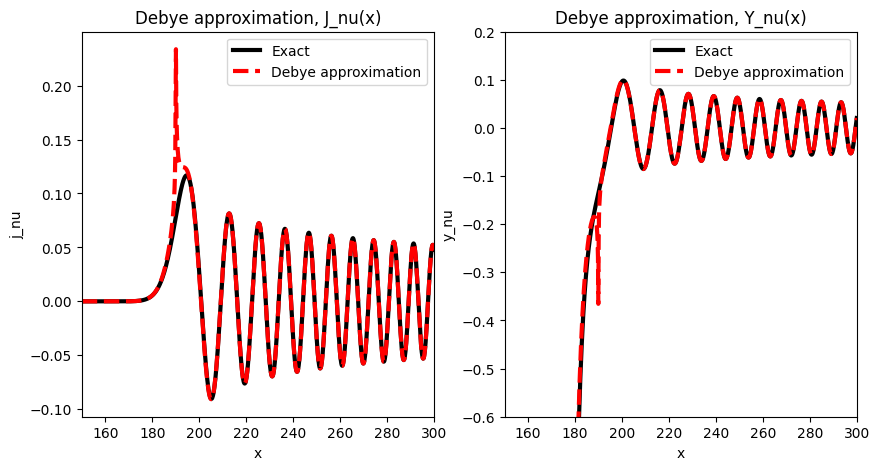

In [189]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.plot(x, jv_exact, color="black", linewidth=3, label="Exact")
ax1.plot(x, jv_approx, color="red", linestyle="dashed", linewidth=3, label="Debye approximation")
ax1.set_xlim(x.min(), x.max());

ax2.plot(x, yv_exact, color="black", linewidth=3, label="Exact")
ax2.plot(x, yv_approx, color="red", linestyle="dashed", linewidth=3, label="Debye approximation")
ax2.set_xlim(x.min(), x.max());
ax2.set_ylim(-0.6, 0.2);

ax1.legend()
ax2.legend()
ax1.set_title("Debye approximation, J_nu(x)")
ax2.set_title("Debye approximation, Y_nu(x)");
ax1.set_ylabel("j_nu")
ax2.set_ylabel("y_nu")
ax1.set_xlabel("x")
ax2.set_xlabel("x");

### Now we do approximations for the derivatives of the Bessel functions of the first and second kind, $J_m'(x), Y_m'(x)$, again for large orders

In [190]:
M = 1000
x = linspace(150, 300, M)

#jv_prime_exact = jvp(m, x, 1)
#jv_prime_approx = j_nu_prime_approximation(x, m)

jv_prime_exact = jvp(m, x, 1)
jv_prime_approx = j_nu_prime_approximation_closed_form(x, m)

#yv_prime_exact = yvp(m, x, 1)
#yv_prime_approx = y_nu_prime_approximation(x, m)

yv_prime_exact = yvp(m, x, 1)
yv_prime_approx = y_nu_prime_approximation_closed_form(x, m)

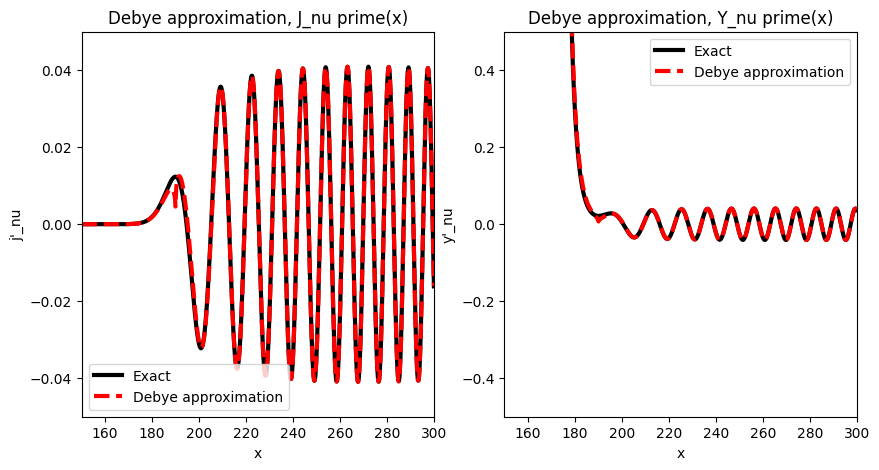

In [191]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.plot(x, jv_prime_exact, color="black", linewidth=3, label="Exact")
ax1.plot(x, jv_prime_approx, color="red", linestyle="dashed", linewidth=3, label="Debye approximation")
ax1.set_xlim(x.min(), x.max());
ax1.set_ylim(-0.05, 0.05)

ax2.plot(x, yv_prime_exact, color="black", linewidth=3, label="Exact")
ax2.plot(x, yv_prime_approx, color="red", linestyle="dashed", linewidth=3, label="Debye approximation")
ax2.set_xlim(x.min(), x.max());
ax2.set_ylim(-0.5, 0.5);

ax1.legend()
ax2.legend()
ax1.set_title("Debye approximation, J_nu prime(x)")
ax2.set_title("Debye approximation, Y_nu prime(x)");
ax1.set_ylabel("j'_nu")
ax2.set_ylabel("y'_nu")
ax1.set_xlabel("x")
ax2.set_xlabel("x");

### With these approximations in place, we see how well the Debye approximation does in giving us an approximation to $\sigma_{CPA}$, the conductivity required for coherent perfect absorption of light by a coated cylindrical scatterer. The CPA conductivity should be given by: 

$\begin{align*}
\sigma/(c\varepsilon_0) = i\Bigg[\frac{\sqrt{\varepsilon}J_m(k^-)}{J_m'(k^-)} -\frac{H_m^{(2)}(k^+)}{H_m^{(2)}(k^+)'}\Bigg] 
\end{align*}$, 

where $k^+\equiv \omega/c$, $k^-\equiv \sqrt{\varepsilon}\omega/c$

### In order to verify that $\sigma_{CPA}(k^++1/\varepsilon, m+1)=\sigma_{CPA}(k^+, m)$, we shift the $x$ axis for $m=191$ and $m=192$. 

In [197]:
epsilon = 4
index = sqrt(epsilon)
m_v = [190, 191, 192]
m_initial = m_v[0]
sigma_debye_v = []
sigmas_exact_v = []

x_initial = linspace(0.5*m_initial/index, m_initial, M)
for (m_idx, m) in enumerate(m_v):
    print(f"m: {m-m_initial}")
    x = linspace(0.5*m_initial/index+(m-m_initial)/index, m_initial+(m-m_initial)/index, M)
    y = x * index # epsilonkR in the cylinder
    jv_y_approx = j_nu_approximation(y, m) # Approximation for j_nu inside the sphere
    jv_x_approx = j_nu_approximation(x, m) # Approximation for j_nu outside the sphere
    yv_x_approx = y_nu_approximation(x, m) # Approximation of y_nu outside of the sphere
    
    jv_y_prime_approx = j_nu_prime_approximation_closed_form(y, m) # Approximation for the derivative of j_nu inside the sphere
    jv_x_prime_approx = j_nu_prime_approximation_closed_form(x, m) # Approximation for the derivative of j_nu outside the sphere
    yv_x_prime_approx = y_nu_prime_approximation_closed_form(x, m) # Approximation for the derivative of y_nu outside the sphere
    sigma_debye = 1j*(index*jv_y_approx/jv_y_prime_approx - (jv_x_approx - 1j*yv_x_approx)/(jv_x_prime_approx - 1j*yv_x_prime_approx))
    sigma_debye_v.append(sigma_debye)

    y_x = yv(m, x); 
    j_yprime = jvp(m, y);
    j_xprime = jvp(m, x);
    j_x = jv(m, x);
    j_y = jv(m, y)
    y_xprime = yvp(m, x)
    prefac = 1/(j_yprime*(j_xprime**2+y_xprime**2))
    mat = np.array([[y_xprime, j_xprime], [-j_xprime, y_xprime]])
    vec = np.array([j_x*j_yprime-index*j_xprime*j_y, index*j_y*y_xprime-y_x*j_yprime])
    sigmas_exact = prefac * np.einsum("ijk, jk -> ik", mat, vec)
    sigmas_exact_v.append(sigmas_exact)

m: 0
m: 1
m: 2


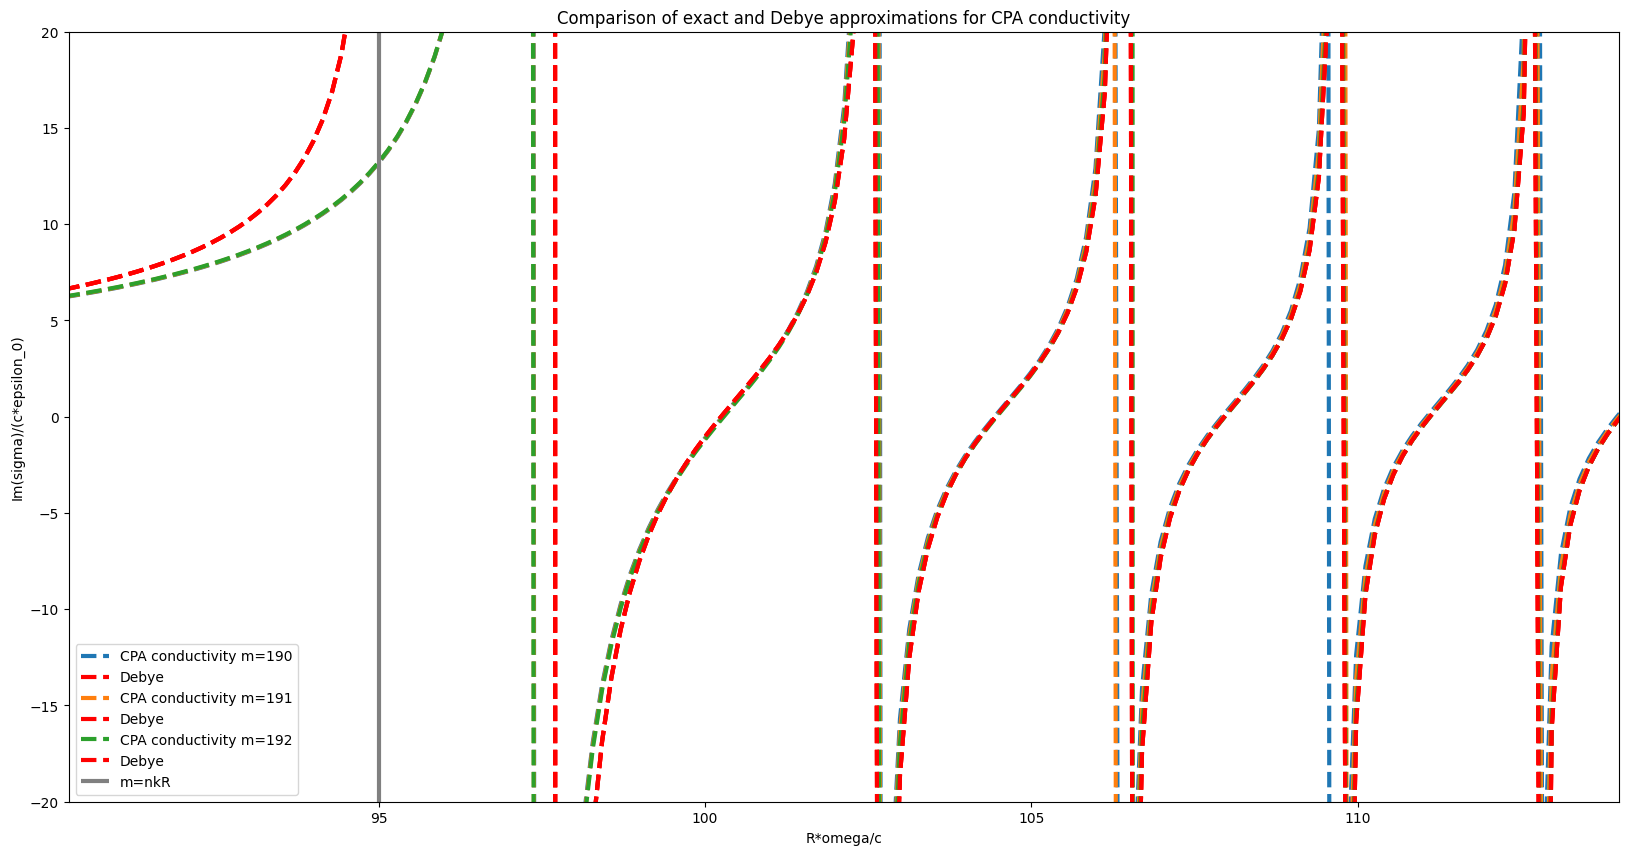

In [214]:
fig, ax = plt.subplots(figsize=(20, 10))

for (m_idx, m) in enumerate(m_v):
    ax.plot(x_initial, sigmas_exact_v[m_idx][1, :], linestyle="dashed", linewidth=3, label=f"CPA conductivity m={m}")
    ax.plot(x_initial, sigma_debye.imag, color="red", linestyle="dashed", linewidth=3, label="Debye")
    ax.set_ylim(-20, 20)
    ax.set_title("Comparison of exact and Debye approximations for CPA conductivity");
    ax.set_ylabel("Im(sigma)/(c*epsilon_0)");
    ax.set_xlim(0.95*m_initial/sqrt(epsilon), 1.2*m_initial/sqrt(epsilon))
    ax.set_xlabel("R*omega/c");
ax.vlines([m_initial/sqrt(epsilon)], -100, 100, color="Grey", linewidth=3, label="m=nkR");
ax.legend();

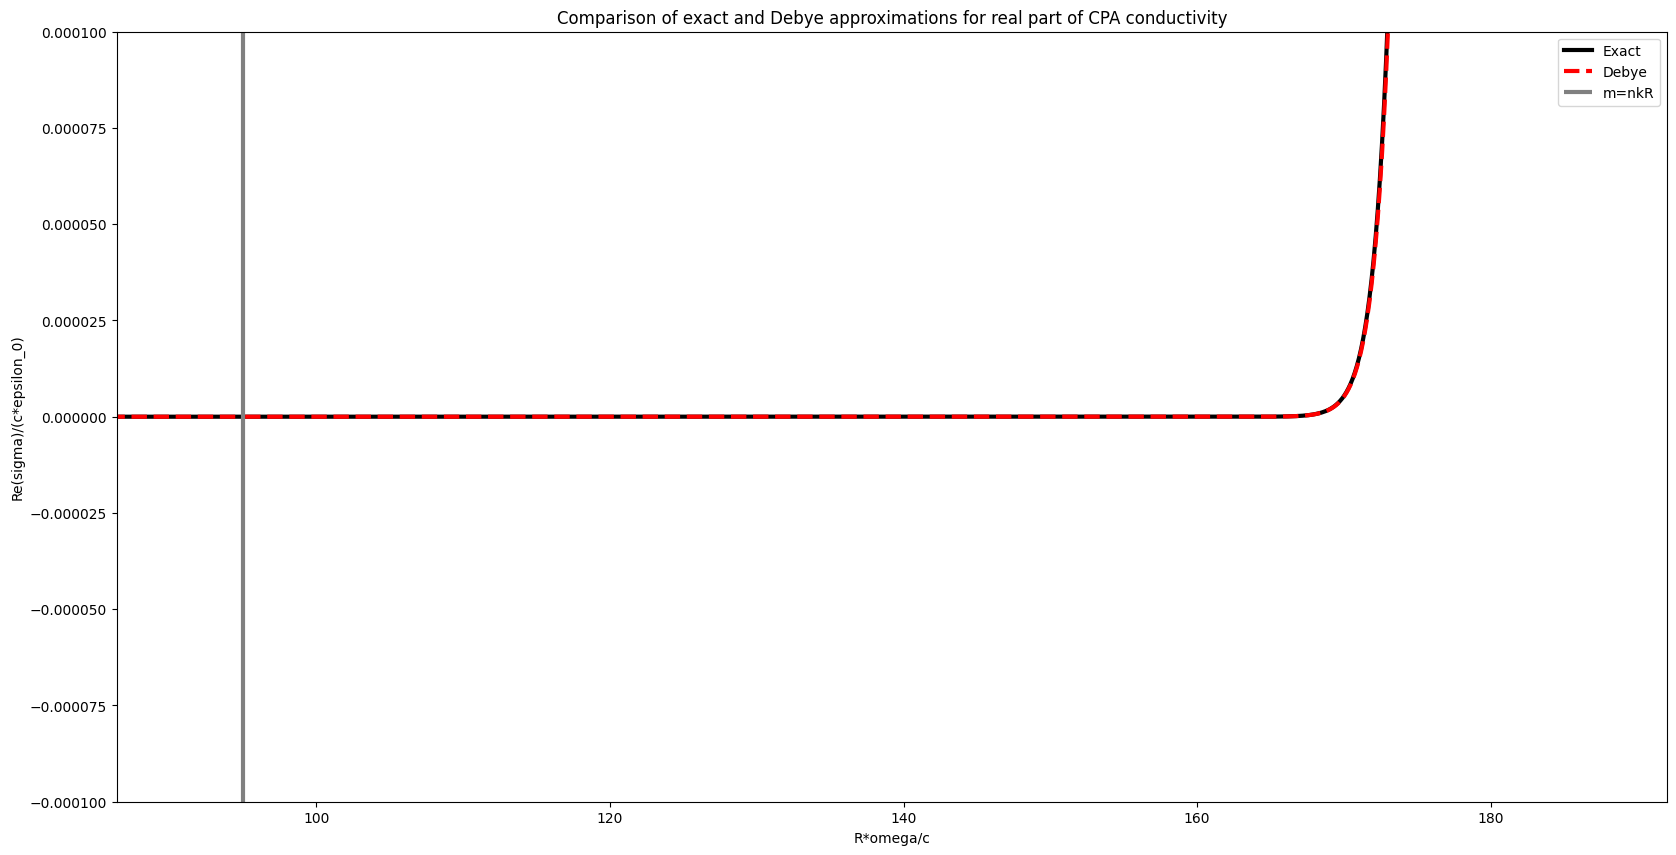

In [221]:
fig, ax = plt.subplots(figsize=(20, 10))
ax.plot(x_initial, sigmas_exact_v[0][0, :], linestyle="solid", color="black", linewidth=3, label="Exact")
ax.plot(x_initial, sigma_debye_v[0].real, color="red", linestyle="dashed", linewidth=3, label="Debye")
ax.set_title("Comparison of exact and Debye approximations for real part of CPA conductivity")
ax.set_ylim(-0.0001, 0.0001);
ax.set_ylabel("Re(sigma)/(c*epsilon_0)")
#ax.set_xlim(x.min(), x.max());
ax.set_xlim(0.9*m/index, m)
ax.set_xlabel("R*omega/c");
ax.vlines([m_initial/sqrt(epsilon)], -100, 100, color="Grey", linewidth=3, label="m=nkR");
ax.legend();

In [223]:
m = 190
alpha = acosh(m/x_initial)
beta = acos(m/(x_initial*index))
f_m_beta = m*tan(beta)-m*beta-pi/4
sigma_debye_closed_form = -1j*(index/tan(f_m_beta)/sin(beta))

### Below, we compare two approximations to the imaginary part of the CPA conductivity with the exact result. 

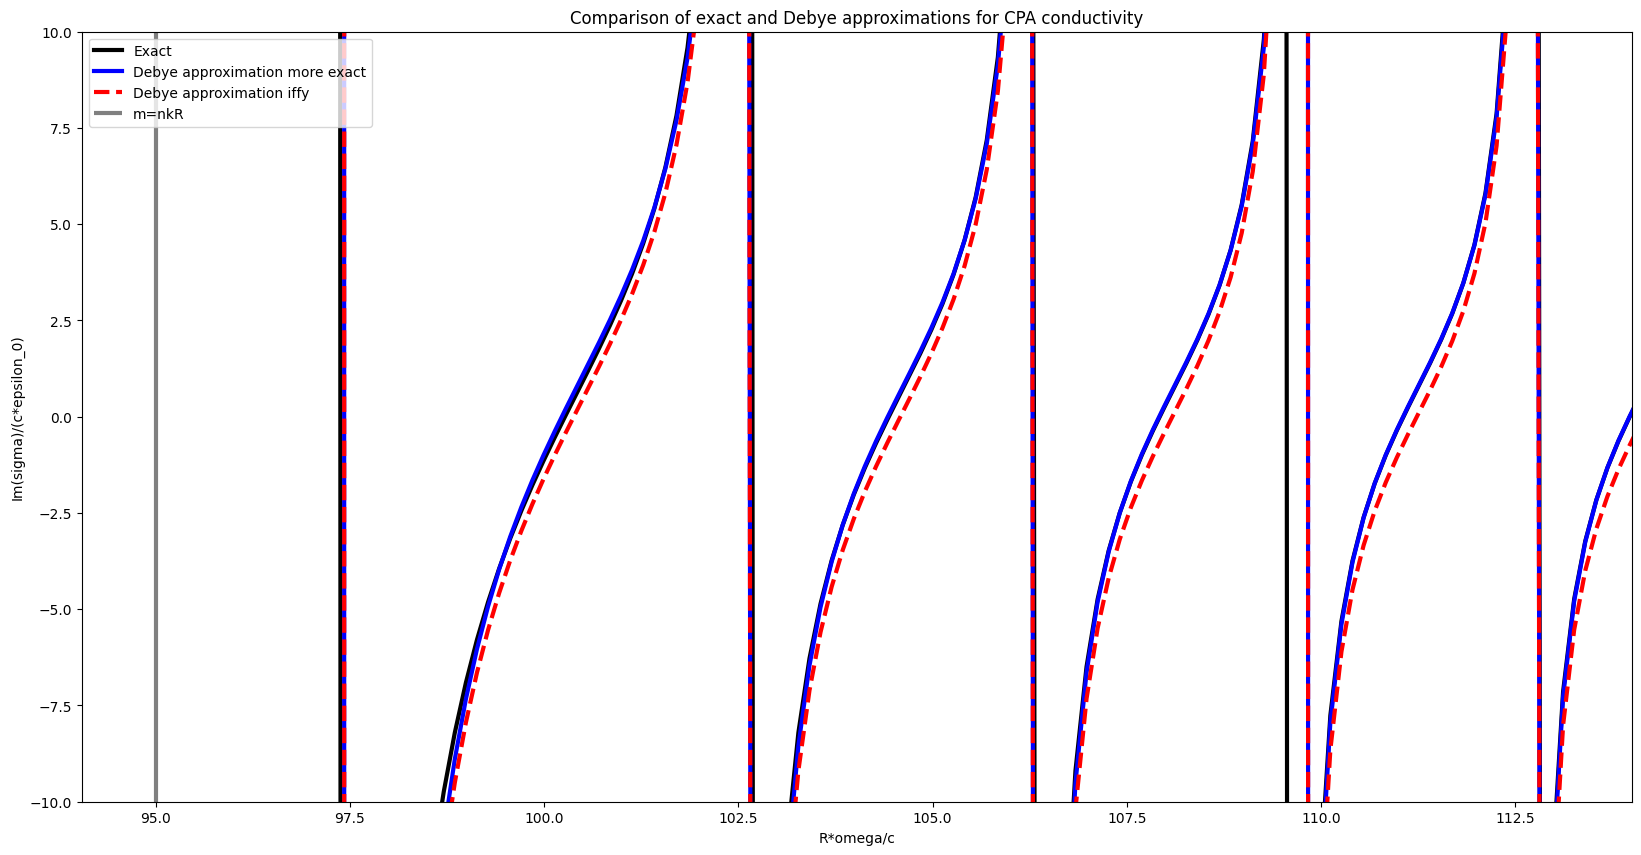

In [243]:
fig, ax = plt.subplots(figsize=(20, 10))
ax.plot(x_initial, sigmas_exact_v[0][1, :], linestyle="solid", color="black", linewidth=3, label="Exact")
ax.plot(x_initial, sigma_debye_v[0].imag, color="blue", linestyle="solid", linewidth=3, label="Debye approximation more exact")
ax.plot(x_initial, sigma_debye_closed_form.imag, color="red", linestyle="dashed", linewidth=3, label="Debye approximation iffy")
ax.set_ylim(-10, 10)
ax.set_title("Comparison of exact and Debye approximations for CPA conductivity");
ax.set_ylabel("Im(sigma)/(c*epsilon_0)");
ax.set_xlim(x_initial.min(), x_initial.max());
ax.set_xlim(m/sqrt(epsilon)*0.99, 1.2*m/sqrt(epsilon))
ax.set_xlabel("R*omega/c");
ax.vlines([m_initial/sqrt(epsilon)], -100, 100, color="Grey", linewidth=3, label="m=nkR");
ax.legend();